In [3]:
import pandas as pd
from scipy.special import binom
from tqdm import tqdm
from itertools import combinations
from pathlib import Path
from collections import defaultdict

import matplotlib as mpl

mpl.rcParams.update(mpl.rcParamsDefault)
import numpy as np
import matplotlib.pyplot as plt

get_ipython().run_line_magic("matplotlib", "inline")
font = {"weight": "normal", "size": 14, "family": "DejaVu Sans"}
plt.rc("text", usetex=True)
plt.rc("font", **font)
import json

def rec_dd():
    return defaultdict(rec_dd)


In [4]:
def pairwise_evaluation(df, partition, ground_truth="simulations"):
    TP = 0
    P = binom(df.groupby([ground_truth]).size(), 2).sum()
    TP_FP = binom(df.groupby([partition]).size(), 2).sum()
    for _, family in tqdm(df.groupby([ground_truth]), disable=True):
        for r1, r2 in combinations(family[partition], 2):
            if r1 == r2:
                TP += 1
    if TP_FP == 0:
        return 0.0, 1.0
    elif P == 0:
        return None, None
    return (
        TP / P,
        TP / TP_FP,
    )  # sensitivity, precision

def entropy(dfGrouped):
    fs = dfGrouped.size()
    fs = fs / sum(fs)
    return sum(fs * np.log2(fs))


def variation_of_info(df, result):
    VI = (
        entropy(df.groupby(["simulations"]))
        + entropy(df.groupby([result]))
        - 2 * entropy(df.groupby([result, "simulations"]))
    )
    return VI


# CDR synth

In [5]:
benchmark_path = Path(
    "/home/gathenes/gitlab/HILARy/data_with_scripts/benchmark_on_synthetic_dataset"
)


In [6]:

metric_dict_synth = rec_dd()
for set in [1, 2, 3, 4, 5]:
    prec_list = []
    sens_list = []
    var_list = []
    for l in range(15, 48, 3):
        dataframe = pd.DataFrame()
        for model in [
            "hilary-full-1-2-0",
            "hilary-full-1-3-0-vjl",
            "hilary-cdr3-1-3-0-vjl",
            "hilary-CDR3-1-2-0",
        ]:
            print(set, l, model)
            if model=='hilary-full-1-2-0':
                df = pd.read_csv(
                    benchmark_path
                    / Path(
                        f"{model}/set{set}/inferred_full_method_families{set}_1e4_ppost326651_mut326713_cdr3l{l}.csv"
                    ),
                )
                df["sequence_id"] = df["sequence_id"].str.strip("-igh")
                df.set_index("sequence_id")
                dataframe[model] = df["family"]
                dataframe["simulations"] = df["FAMILY"]
            elif model.startswith("hilary-full-1-3-0"):
                df = pd.read_csv(
                    benchmark_path
                    / Path(
                        f"{model}/set{set}/inferred_full_method_families{set}_1e4_ppost326651_mut326713_cdr3l{l}.csv"
                    ),
                )
                df["sequence_id"] = df["sequence_id"].str.strip("-igh")
                df.set_index("sequence_id")
                dataframe[model] = df["clone_id"]
            elif model.startswith("hilary-CDR3"):
                df = pd.read_csv(
                    benchmark_path
                    / Path(
                        f"{model}/set{set}/inferred_cdr3_based_families{set}_1e4_ppost326651_mut326713_cdr3l{l}.csv"
                    ),
                )
                df["sequence_id"] = df["sequence_id"].str.strip("-igh")
                df.set_index("sequence_id")
                dataframe[model] = df["cdr3_based_family"]
            elif model.startswith("hilary-cdr3"):
                df = pd.read_csv(
                    benchmark_path
                    / Path(
                        f"{model}/set{set}/inferred_cdr3_based_families{set}_1e4_ppost326651_mut326713_cdr3l{l}.csv"
                    ),
                )
                df["sequence_id"] = df["sequence_id"].str.strip("-igh")
                df.set_index("sequence_id")
                dataframe[model] = df["clone_id"]

            sensitivity, precision = pairwise_evaluation(dataframe, model)
            varinfo = variation_of_info(dataframe, model)
            metric_dict_synth[model]["precision"][l][set] = precision
            metric_dict_synth[model]["sensitivity"][l][set] = sensitivity
            metric_dict_synth[model]["variation_of_info"][l][set] = varinfo


1 15 hilary-full-1-2-0
1 15 hilary-full-1-3-0-vjl
1 15 hilary-cdr3-1-3-0-vjl
1 15 hilary-CDR3-1-2-0
1 18 hilary-full-1-2-0
1 18 hilary-full-1-3-0-vjl
1 18 hilary-cdr3-1-3-0-vjl
1 18 hilary-CDR3-1-2-0
1 21 hilary-full-1-2-0
1 21 hilary-full-1-3-0-vjl
1 21 hilary-cdr3-1-3-0-vjl
1 21 hilary-CDR3-1-2-0
1 24 hilary-full-1-2-0
1 24 hilary-full-1-3-0-vjl
1 24 hilary-cdr3-1-3-0-vjl
1 24 hilary-CDR3-1-2-0
1 27 hilary-full-1-2-0
1 27 hilary-full-1-3-0-vjl
1 27 hilary-cdr3-1-3-0-vjl
1 27 hilary-CDR3-1-2-0
1 30 hilary-full-1-2-0
1 30 hilary-full-1-3-0-vjl
1 30 hilary-cdr3-1-3-0-vjl
1 30 hilary-CDR3-1-2-0
1 33 hilary-full-1-2-0
1 33 hilary-full-1-3-0-vjl
1 33 hilary-cdr3-1-3-0-vjl
1 33 hilary-CDR3-1-2-0
1 36 hilary-full-1-2-0
1 36 hilary-full-1-3-0-vjl
1 36 hilary-cdr3-1-3-0-vjl
1 36 hilary-CDR3-1-2-0
1 39 hilary-full-1-2-0
1 39 hilary-full-1-3-0-vjl
1 39 hilary-cdr3-1-3-0-vjl
1 39 hilary-CDR3-1-2-0
1 42 hilary-full-1-2-0
1 42 hilary-full-1-3-0-vjl
1 42 hilary-cdr3-1-3-0-vjl
1 42 hilary-CDR3-1-2-0


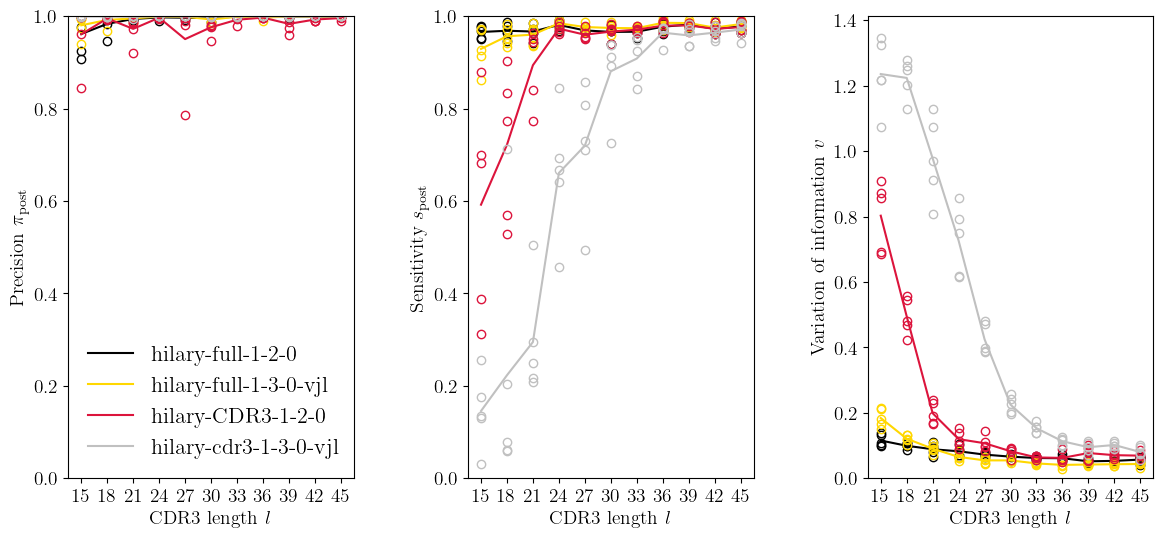

In [7]:
ls = np.arange(15, 45 + 3, 3)
fig = plt.figure(figsize=(14, 6))

limits = {
    "hilary-full": 2e4,
    "hilary-cdr3": 1e4,
}

colors = {
    "hilary-full-1-2-0": "k",
    "hilary-full-1-3-0-vjl": "gold",
    "hilary-full-1-3-0-l": "pink",
    "hilary-CDR3-1-2-0": "crimson",
    "hilary-cdr3-1-3-0-vjl": "silver",
    "hilary-cdr3-1-3-0-l": "green",
}

ax1 = fig.add_subplot(131)
ax1.set_ylabel(r"Precision $\pi_{\rm post}$")
ax1.set_xlabel(r"CDR3 length $l$")

ax2 = fig.add_subplot(132)
ax2.set_ylabel(r"Sensitivity $s_{\rm post}$")
ax2.set_xlabel(r"CDR3 length $l$")

ax3 = fig.add_subplot(133)
ax3.set_xlabel(r"CDR3 length $l$")

ax3.set_ylabel(r"Variation of information $v$")
axes = [ax1, ax2, ax3]

"-------------------------------------------------------------------------------------------------------------------"

for model in colors:
    label = model
    for i, metric in enumerate(metric_dict_synth[model]):
        for l in metric_dict_synth[model][metric]:
            y = list(metric_dict_synth[model][metric][l].values())
            x = [l] * len(y)
            axes[i].plot(
                x,
                y,
                "o",
                fillstyle="none",
                color=colors[model],
            )
        lengths = []
        averages = []
        for length in metric_dict_synth[model][metric]:
            lengths.append(length)
            averages.append(np.mean(list(metric_dict_synth[model][metric][length].values())))
        axes[i].plot(
            lengths,
            averages,
            color=colors[model],
            label=label,
        )

ax1.set_xticks(ls)
ax1.set_xticklabels(ls)
ax2.set_xticks(ls)
ax2.set_xticklabels(ls)
ax3.set_xticks(ls)
ax3.set_xticklabels(ls)

"-------------------------------------------------------------------------------------------------------"

ax1.set_ylim(bottom=0, top=1)
ax2.set_ylim(bottom=0, top=1)
ax3.set_ylim(bottom=0)

ax1.legend(frameon=False, fontsize=16)

fig.subplots_adjust(wspace=0.4)
fig.subplots_adjust(hspace=0.4)
plt.savefig("/home/gathenes/gitlab/HILARy/data_with_scripts/article_figure_scripts/paper_figure4_toprow.png")
plt.show()